# Лабораторная работа №6, вариант 8

### Цель работы: научиться решать задачу классификации методами решающих деревьев и ансамблей на их основе.

#### Вариант 8 – Обнаружение нестабильной электрической сети 


Датасет – electrical_grid.csv 

Набор данных содержит 10 000 наблюдений. Он также содержит 12 основных 
прогностических признаков и зависимую переменную. 




• Прогностические функции: 


tau1 – tau4: время реакции каждого участника сети, действительное значение в 
диапазоне от 0,5 до 10 (tau1 соответствует узлу-поставщику, tau2 – tau4 – узлам-по
требителям); 


p1 до'p4: номинальная мощность, произведенная (положительная) или потреб
ленная (отрицательная) каждым участником сети, реальное значение в диапазоне от 
2,0 до -0,5 для потребителей (p2 до p4). Поскольку общая потребляемая мощность 
равна общей генерируемой мощности, p1 (узел-поставщик) = - (p2 + p3 + p4); 


g1 – g4: коэффициент ценовой эластичности для каждого участника сети, дей
ствительное значение в диапазоне от 0,05 до 1,00 (g1 соответствует узлу-поставщику, 
g2 – g4 – узлам-потребителям; g означает гамма); 


• Зависимая переменная: 


stabf: категориальная (бинарная) метка («стабильный» или «нестабильный»). 

**1. Импортируйте необходимые библиотеки**

In [8]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns  

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV  
from sklearn.tree import DecisionTreeClassifier, plot_tree  
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier  
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay  

**2. Ззагружаем данные и проводим первичный анализ данных**

In [9]:
df = pd.read_csv('electrical_grid.csv')
X = df.drop(columns=['stabf'])
y = df['stabf']
print("Размерность признаков:", X.shape)
print("Названия признаков:", X.columns.tolist())
print("Размерность целевой переменной:", y.shape)
print("Уникальные классы:", y.unique())
print("\nПервые 5 строк признаков:")
print(X.head())

Размерность признаков: (10000, 12)
Названия признаков: ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']
Размерность целевой переменной: (10000,)
Уникальные классы: ['unstable' 'stable']

Первые 5 строк признаков:
       tau1      tau2      tau3      tau4        p1        p2        p3  \
0  2.959060  3.079885  8.381025  9.780754  3.763085 -0.782604 -1.257395   
1  9.304097  4.902524  3.047541  1.369357  5.067812 -1.940058 -1.872742   
2  8.971707  8.848428  3.046479  1.214518  3.405158 -1.207456 -1.277210   
3  0.716415  7.669600  4.486641  2.340563  3.963791 -1.027473 -1.938944   
4  3.134112  7.608772  4.943759  9.857573  3.525811 -1.125531 -1.845975   

         p4        g1        g2        g3        g4  
0 -1.723086  0.650456  0.859578  0.887445  0.958034  
1 -1.255012  0.413441  0.862414  0.562139  0.781760  
2 -0.920492  0.163041  0.766689  0.839444  0.109853  
3 -0.997374  0.446209  0.976744  0.929381  0.362718  
4 -0.554305  0.797110  0.455450  0

**3. Разделение данных на обучающую и тестовую выборки**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (8000, 12)
Размер тестовой выборки: (2000, 12)


**4. Построение и оценка базового дерева решений**

In [11]:
# Создаем и обучаем модель дерева решений без настройки гиперпараметров
base_dt = DecisionTreeClassifier(random_state=42)
base_dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
# Делаем прогнозы
y_pred_base = base_dt.predict(X_test)
# Оцениваем точность
accuracy_base = accuracy_score(y_test, y_pred_base)
print(f"Точность базового дерева на тесте: {accuracy_base:.4f}")

Точность базового дерева на тесте: 0.8495


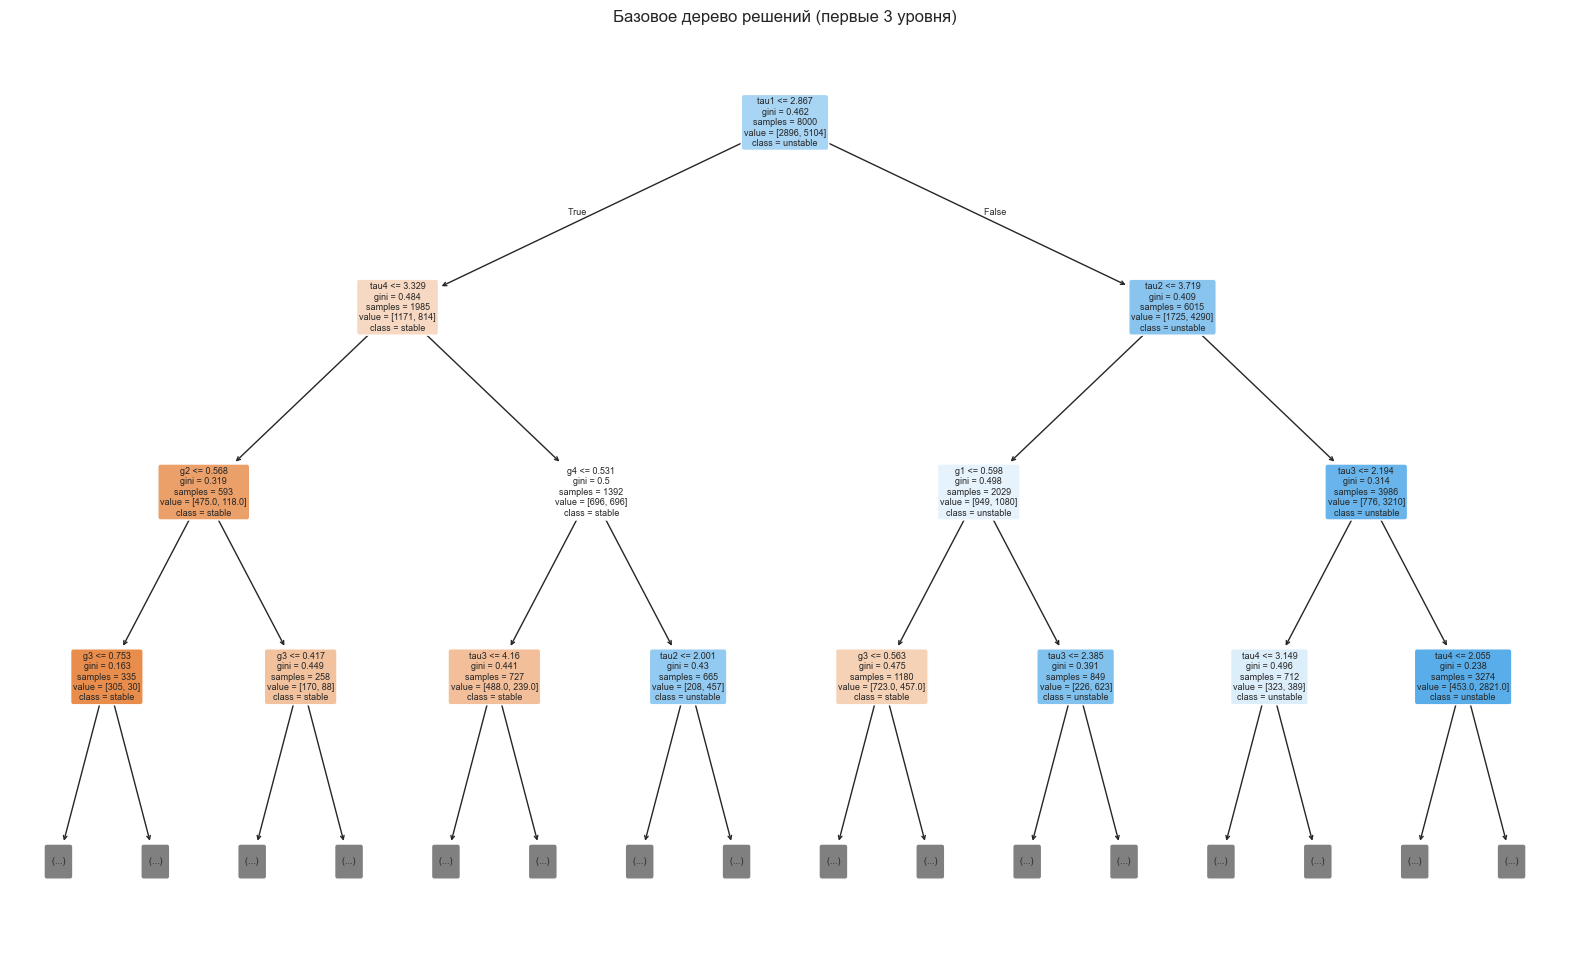

In [14]:
plt.figure(figsize=(20, 12))
plot_tree(base_dt, filled=True, feature_names=X.columns, class_names=sorted(y.unique()), rounded=True, max_depth=3)
plt.title("Базовое дерево решений (первые 3 уровня)")
plt.show()

**Борьба с переобучением: настройка гиперпараметров**

In [19]:
# Попробуем ограничить глубину дерева
tuned_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
tuned_dt.fit(X_train, y_train)

y_pred_tuned = tuned_dt.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Точность настроенного дерева (max_depth=3) на тесте: {accuracy_tuned:.4f}")

Точность настроенного дерева (max_depth=3) на тесте: 0.7215


In [20]:
# Кросс-валидация для более надежной оценки
cv_scores_base = cross_val_score(base_dt, X, y, cv=5)
cv_scores_tuned = cross_val_score(tuned_dt, X, y, cv=5)

print(f"Кросс-валидация, базовое дерево: {np.mean(cv_scores_base):.4f} (+/- {np.std(cv_scores_base) * 2:.4f})")
print(f"Кросс-валидация, настроенное дерево: {np.mean(cv_scores_tuned):.4f} (+/- {np.std(cv_scores_tuned) * 2:.4f})")

Кросс-валидация, базовое дерево: 0.8395 (+/- 0.0169)
Кросс-валидация, настроенное дерево: 0.7274 (+/- 0.0219)


Ограничение глубины дерева до 3 уровней снизило точность до 72.15%, но уменьшило переобучение.

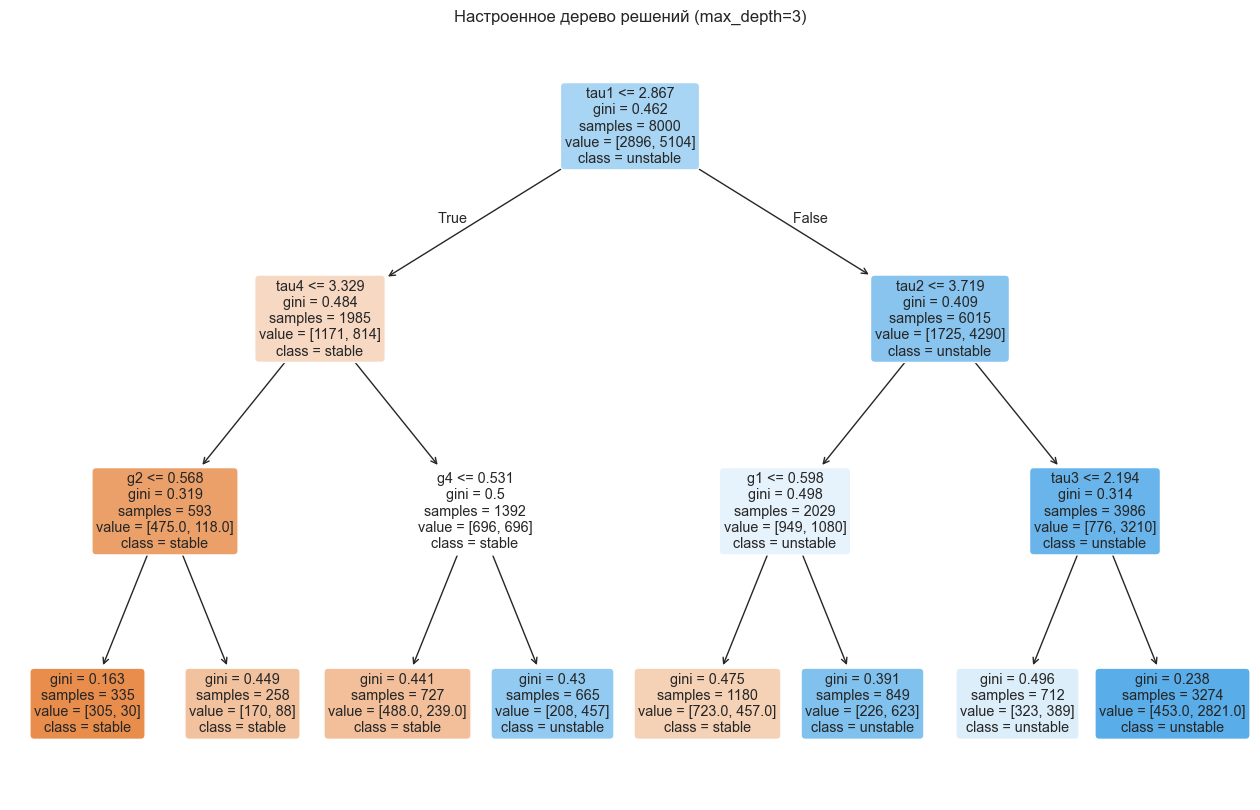

In [21]:
# Визуализируем настроенное дерево
plt.figure(figsize=(16, 10))
plot_tree(tuned_dt, filled=True, feature_names=X.columns, class_names=sorted(y.unique()), rounded=True)
plt.title("Настроенное дерево решений (max_depth=3)")
plt.show()

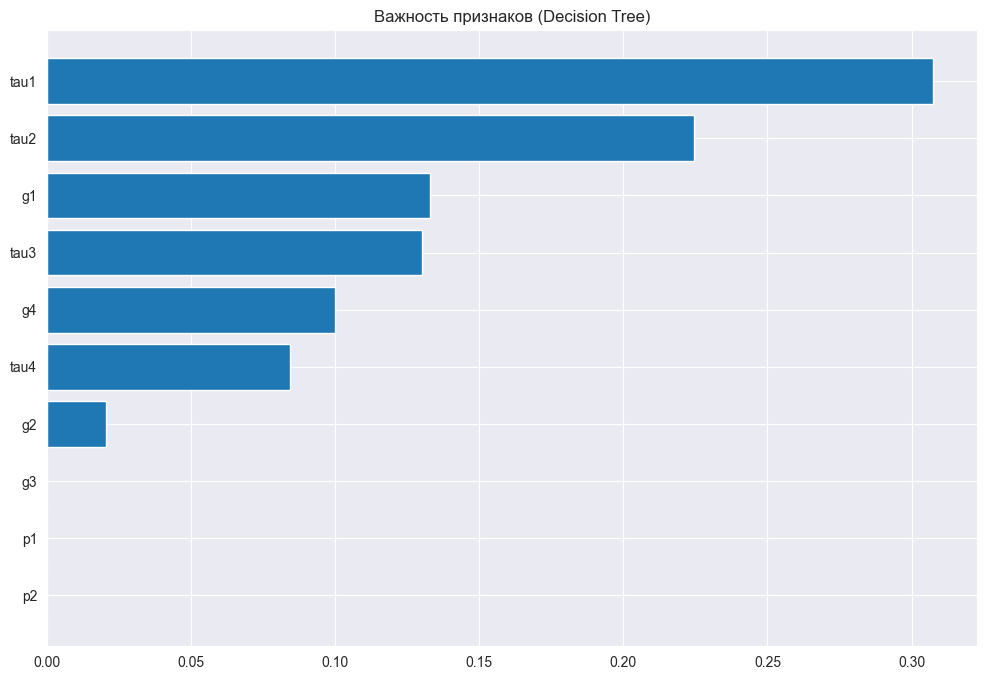

In [22]:
# Важность признаков
importances = tuned_dt.feature_importances_  
indices = np.argsort(importances)[::-1]  
plt.figure(figsize=(12, 8))  
plt.title("Важность признаков (Decision Tree)")  
plt.barh(range(10), importances[indices][:10]) # Топ-10 признаков  
plt.yticks(range(10), [X.columns[i] for i in indices[:10]])
plt.gca().invert_yaxis()  
plt.show()

Диаграмма показывает важность признаков для одиночного дерева. Наиболее значимы tau1, tau2 и g1. Признаки мощности (p1, p2) и g3 практически не влияют на предсказание в этой модели.

**5. Создание и обучение модели Random Forest**

In [23]:
# Создаем модель Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Обучаем модель на обучающих данных
rf_model.fit(X_train, y_train)

print("Модель Random Forest обучена!")

Модель Random Forest обучена!


**6. Прогнозирование и оценка модели**

In [24]:
# Делаем прогнозы на тестовой выборке
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели на тестовой выборке: {accuracy:.4f}")

Точность модели на тестовой выборке: 0.9240


In [25]:
# Выводим подробный отчет по классификации
print("\n" + "="*50)
print("Отчет по классификации:")
print("="*50)
print(classification_report(y_test, y_pred))


Отчет по классификации:
              precision    recall  f1-score   support

      stable       0.93      0.86      0.89       724
    unstable       0.92      0.96      0.94      1276

    accuracy                           0.92      2000
   macro avg       0.92      0.91      0.92      2000
weighted avg       0.92      0.92      0.92      2000



Модель показывает высокую общую точность. Класс unstable предсказывается лучше: полнота (recall) 96%, точность (precision) 92%. Для класса stable полнота ниже — 86%, хотя точность остаётся высокой (93%). Это указывает на небольшое смещение модели в сторону класса unstable, возможно из-за дисбаланса данных (unstable объектов почти вдвое больше). В целом модель эффективна.



**7. Матрица ошибок**

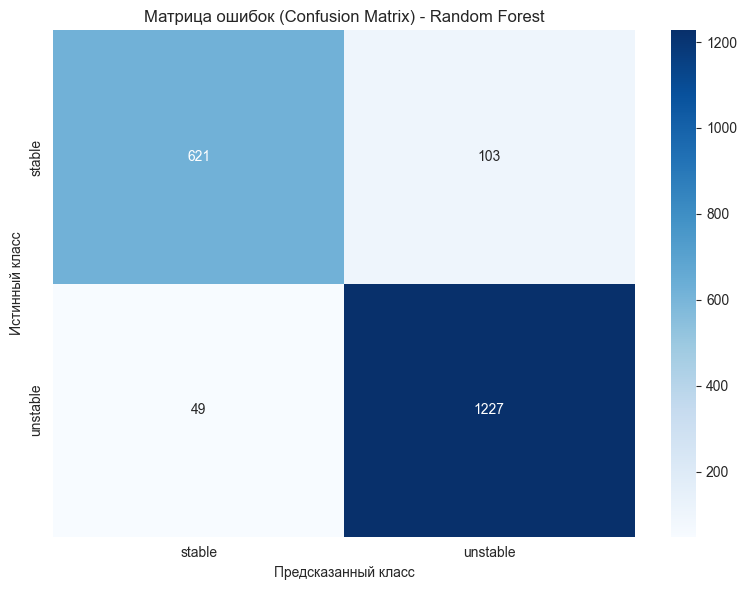

In [26]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))
plt.title('Матрица ошибок (Confusion Matrix) - Random Forest')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

Матрица ошибок подтверждает, что модель имеет смещение в сторону класса unstable — она чаще ошибочно предсказывает стабильность как нестабильность (103 случая), чем наоборот (49 случаев).

**8. Анализ важности признаков**

In [27]:
# Важность признаков на основе среднего уменьшения неоднородности
feature_importances = rf_model.feature_importances_
features_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importances})
features_df = features_df.sort_values('importance', ascending=False)

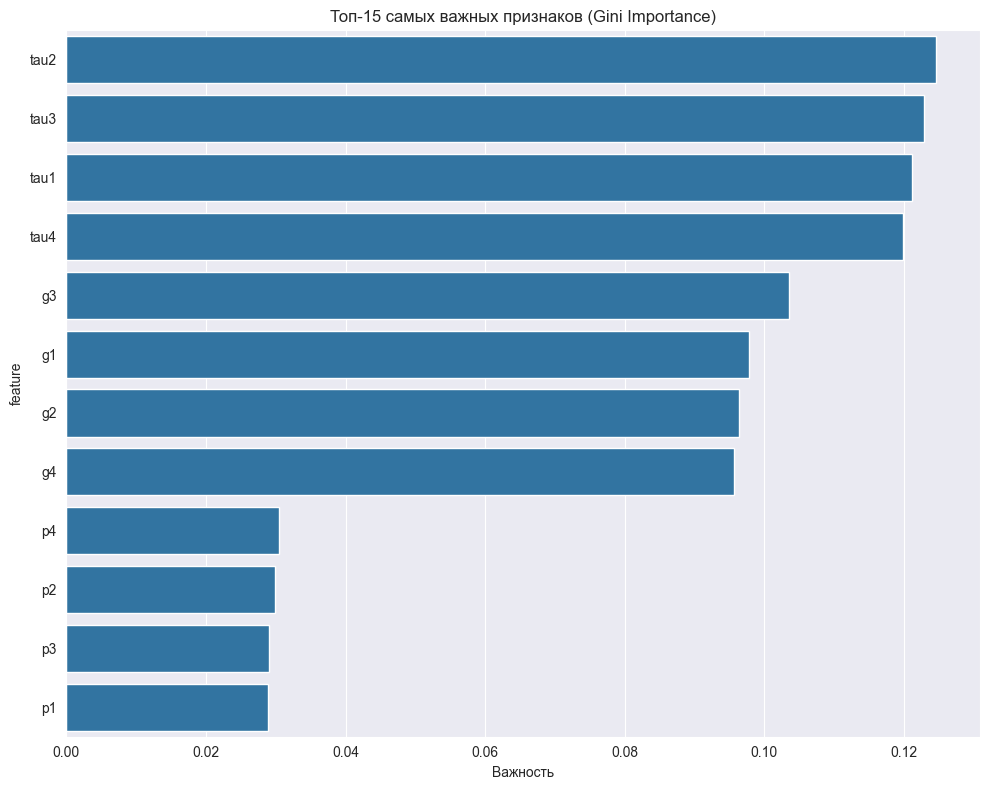

In [28]:
# Визуализация важности признаков
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=features_df.head(15))  # Покажем топ-15 признаков
plt.title('Топ-15 самых важных признаков (Gini Importance)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

In [29]:
print("Топ-10 самых важных признаков:")
print(features_df.head(10))

Топ-10 самых важных признаков:
   feature  importance
1     tau2    0.124661
2     tau3    0.122901
0     tau1    0.121103
3     tau4    0.119865
10      g3    0.103483
8       g1    0.097852
9       g2    0.096366
11      g4    0.095669
7       p4    0.030442
5       p2    0.029823


Диаграмма важных признаков для Random Forest также выделяет tau2, tau3, tau1, tau4 как главные признаки, за ними идут g3, g1, g2, что подтверждает выводы одиночного дерева — tau и g критически важны. Random Forest учитывает больше взаимодействий между признаками.

**9. Подбор гиперпараметров**

In [30]:
# Определяем сетку параметров для перебора
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [32]:
# Создаем модель для поиска
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, 
                          scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [33]:
# Выводим лучшие параметры
print("\nЛучшие параметры:", grid_search.best_params_)
print(f"Лучшая точность при кросс-валидации: {grid_search.best_score_:.4f}")


Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Лучшая точность при кросс-валидации: 0.9187


In [34]:
# Оцениваем лучшую модель на тестовых данных
best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Точность улучшенной модели на тестовой выборке: {best_accuracy:.4f}")

Точность улучшенной модели на тестовой выборке: 0.9290


**10. Сравнение моделей**

In [36]:
models = {
    'Base Decision Tree': base_dt,          # Базовое дерево решений
    'Tuned Decision Tree (max_depth=3)': tuned_dt,  # Настроенное дерево
    'Random Forest (100 trees)': rf_model,  # Случайный лес
    'Best Random Forest (GridSearch)': best_rf_model  # Лучшая модель после GridSearch
}

results = {}

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Вычисляем точность
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    results[name] = {
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    }

results_df = pd.DataFrame(results).T
print("Сравнение точности моделей:")
print(results_df)

Сравнение точности моделей:
                                   Train Accuracy  Test Accuracy
Base Decision Tree                          1.000         0.8495
Tuned Decision Tree (max_depth=3)           0.747         0.7215
Random Forest (100 trees)                   1.000         0.9240
Best Random Forest (GridSearch)             1.000         0.9290


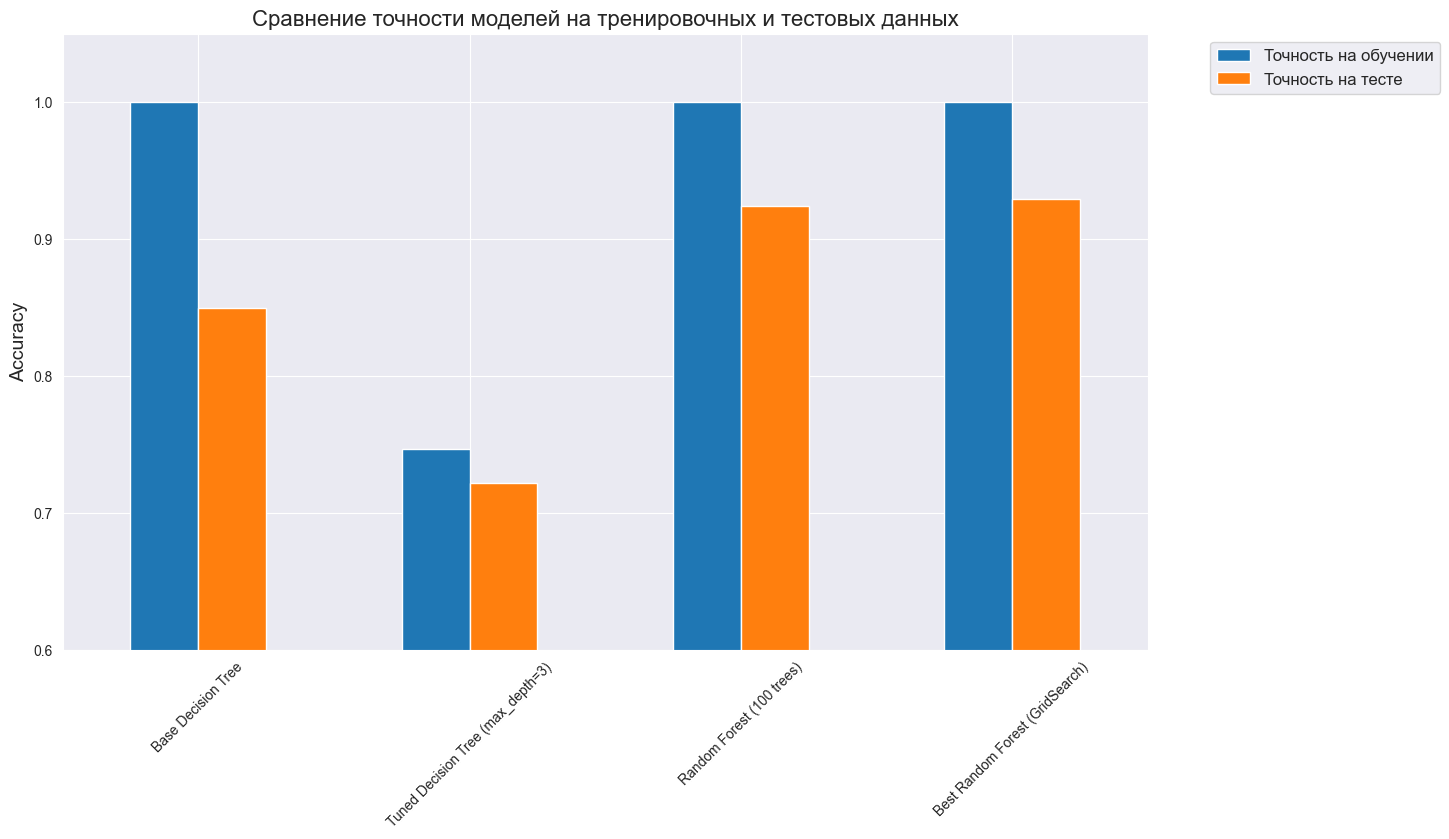

In [46]:
# Bar plot для сравнения точности на тренировочных и тестовых данных
ax = results_df[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', figsize=(14, 8))

plt.title('Сравнение точности моделей на тренировочных и тестовых данных', fontsize=16)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(rotation=45)
plt.ylim(0.6, 1.05)  
# Настройка легенды
plt.legend(['Точность на обучении', 'Точность на тесте'], 
           fontsize=12, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.show()

На основе сравнения моделей видно, что Random Forest значительно превосходит одиночные деревья. Лучший результат показала оптимизированная через GridSearch версия Random Forest с точностью 0.9290 на тесте. Базовый Random Forest (100 деревьев) близок к ней — 0.9240. Одиночные деревья работают хуже: базовое — 0.8495, а упрощенное (max_depth=3) — всего 0.7215.

График четко показывает проблему переобучения: все модели, кроме упрощенного дерева, имеют 100% точность на обучении, но на тесте их результаты падают.

Для задачи классификации стабильности энергосети лучше всего подходит Random Forest, особенно его оптимизированная версия, он дает высокую точность. Упрощенное дерево хоть и меньше переобучается, но слишком неточно для практического использования.